In [1]:
# Required packages should already be installed in the active Python environment.
# Remove pip install commands from the notebook for stability.


# Rubber Leaf Disease Classification with Explainable AI (XAI)

## Overview
This notebook trains an EfficientNetB0 model for rubber leaf disease classification and integrates explainability features using Grad-CAM to make predictions transparent and interpretable.

## Key Features
- **Image Classification**: 8 disease categories (Healthy, Abnormal, Anthracnose, Black_Spot, Dry_Leaf, Leaf_Blight, Leaf_Spot, Powdery_Mildew)
- **Grad-CAM Heatmaps**: Visual explanation of which regions influenced the prediction
- **Severity Estimation**: Quantifies disease severity (Mild/Moderate/Severe)
- **Symptom Detection**: Provides disease-specific symptoms
- **Treatment Guidance**: Actionable recommendations for each disease

## Architecture
Model: EfficientNetB0 (pre-trained on ImageNet)
Input: 224×224 RGB images
Output: 8-class probability distribution
Explainability: Grad-CAM heatmaps from top_activation layer

In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report


In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32

HERE = Path.cwd()
REPO_ROOT = HERE.parent if HERE.name == 'notebooks' else HERE
DATASET_PATH = REPO_ROOT / 'Dataset' / 'Compressed_Dataset'

print(f'Using dataset path: {DATASET_PATH}')
if not DATASET_PATH.exists():
    raise FileNotFoundError(f'Dataset path not found: {DATASET_PATH}')


Using dataset path: c:\Users\88019\OneDrive\Desktop\Thesis\RubberLeaf Diseases\paty\Leaf-Disease-Classification-with-EfficientNet\Dataset\Compressed_Dataset


In [4]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print(train_data.class_indices)


Found 3255 images belonging to 8 classes.
Found 811 images belonging to 8 classes.
{'Abnormal': 0, 'Anthracnose': 1, 'Black_Spot': 2, 'Dry_Leaf': 3, 'Healthy': 4, 'Leaf_Blight': 5, 'Leaf_Spot': 6, 'Powdery_Mildew': 7}


In [5]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.Dropout(0.5),
    layers.Dense(len(train_data.class_indices), activation='softmax')
])


In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [7]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3)
checkpoint = ModelCheckpoint('best_leaf_model.h5', save_best_only=True)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop, reduce_lr, checkpoint]
)


Epoch 1/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 912ms/step - accuracy: 0.2875 - loss: 6.4122

102/102 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.4424 - loss: 5.8325 - val_accuracy: 0.6794 - val_loss: 5.3079 - learning_rate: 1.0000e-04
Epoch 2/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 839ms/step - accuracy: 0.6702 - loss: 4.9886

102/102 ━━━━━━━━━━━━━━━━━━━━ 100s 984ms/step - accuracy: 0.6894 - loss: 4.8820 - val_accuracy: 0.7793 - val_loss: 4.7548 - learning_rate: 1.0000e-04
Epoch 3/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 849ms/step - accuracy: 0.7538 - loss: 4.5767

102/102 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.7674 - loss: 4.4988 - val_accuracy: 0.8175 - val_loss: 4.3971 - learning_rate: 1.0000e-04
Epoch 4/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 784ms/step - accuracy: 0.8089 - loss: 4.2690

102/102 ━━━━━━━━━━━━━━━━━━━━ 95s 929ms/step - accuracy: 0.8104 - loss: 4.2161 - val_accuracy: 0.8224 - val_loss: 4.1492 - learning_rate: 1.0000e-04
Epoch 5/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 774ms/step - accuracy: 0.7951 - loss: 4.0906

...

102/102 ━━━━━━━━━━━━━━━━━━━━ 97s 950ms/step - accuracy: 0.8768 - loss: 2.0345 - val_accuracy: 0.8681 - val_loss: 2.0339 - learning_rate: 1.0000e-04
Epoch 17/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 805ms/step - accuracy: 0.8742 - loss: 1.9456

102/102 ━━━━━━━━━━━━━━━━━━━━ 97s 951ms/step - accuracy: 0.8713 - loss: 1.9128 - val_accuracy: 0.8705 - val_loss: 1.9014 - learning_rate: 1.0000e-04
Epoch 18/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 792ms/step - accuracy: 0.8737 - loss: 1.8225

102/102 ━━━━━━━━━━━━━━━━━━━━ 96s 939ms/step - accuracy: 0.8673 - loss: 1.7920 - val_accuracy: 0.8631 - val_loss: 1.8088 - learning_rate: 1.0000e-04
Epoch 19/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 790ms/step - accuracy: 0.8797 - loss: 1.6884

102/102 ━━━━━━━━━━━━━━━━━━━━ 95s 934ms/step - accuracy: 0.8740 - loss: 1.6671 - val_accuracy: 0.8742 - val_loss: 1.6518 - learning_rate: 1.0000e-04
Epoch 20/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 796ms/step - accuracy: 0.8787 - loss: 1.5762

102/102 ━━━━━━━━━━━━━━━━━━━━ 96s 943ms/step - accuracy: 0.8796 - loss: 1.5544 - val_accuracy: 0.8792 - val_loss: 1.5656 - learning_rate: 1.0000e-04


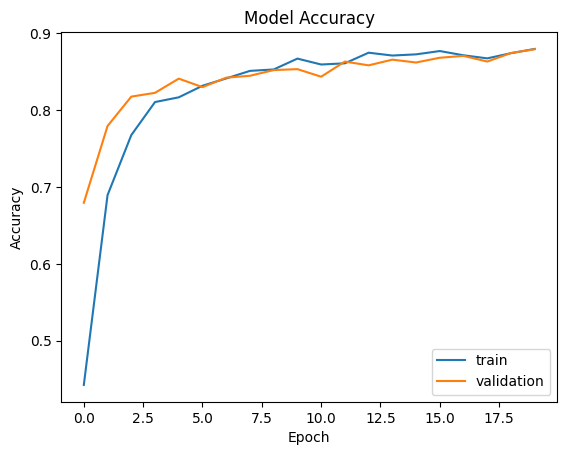

In [8]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 612ms/step


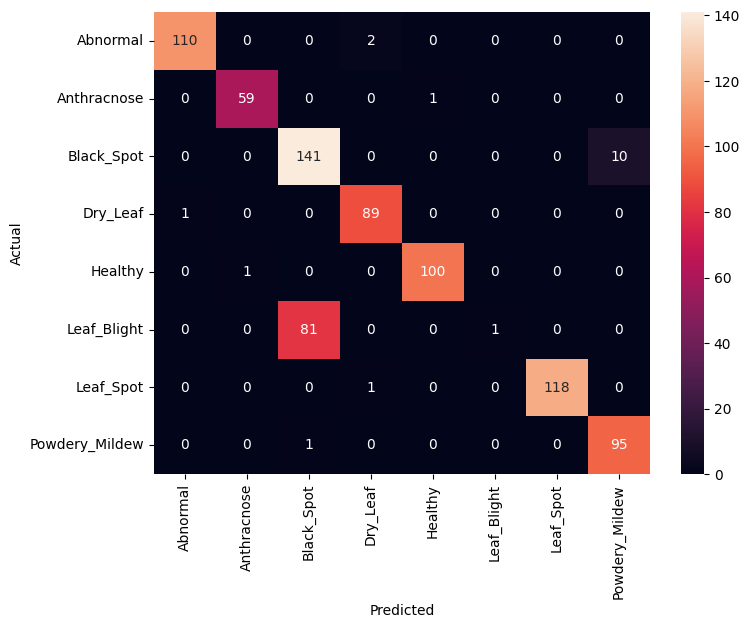

                precision    recall  f1-score   support

      Abnormal       0.99      0.98      0.99       112
   Anthracnose       0.98      0.98      0.98        60
    Black_Spot       0.63      0.93      0.75       151
      Dry_Leaf       0.97      0.99      0.98        90
       Healthy       0.99      0.99      0.99       101
   Leaf_Blight       1.00      0.01      0.02        82
     Leaf_Spot       1.00      0.99      1.00       119
Powdery_Mildew       0.90      0.99      0.95        96

      accuracy                           0.88       811
     macro avg       0.93      0.86      0.83       811
  weighted avg       0.91      0.88      0.84       811



In [9]:
val_data.reset()
pred = model.predict(val_data)
pred_classes = np.argmax(pred, axis=1)
true_classes = val_data.classes
class_labels = list(val_data.class_indices.keys())

cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(true_classes, pred_classes, target_names=class_labels))


In [11]:
def predict_leaf(image_path):
    img = tf.keras.utils.load_img(str(image_path), target_size=(IMG_SIZE, IMG_SIZE))
    img = tf.keras.utils.img_to_array(img)
    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)
    class_names = list(train_data.class_indices.keys())

    print('Prediction:', class_names[np.argmax(prediction)])

def predict_leaf(image_path):
    img = cv2.imread(str(image_path))
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)
    class_names = list(train_data.class_indices.keys())

    print('Prediction:', class_names[np.argmax(prediction)])


In [ ]:
import cv2
import tensorflow as tf

def make_gradcam_heatmap(img_array, model, last_conv_layer_name='top_activation'):
    """Generate Grad-CAM heatmap for image classification"""
    # Create a model that maps the input image to the activations
    # of the last conv layer as well as the output predictions
    last_conv_layer = model.get_layer(last_conv_layer_name)
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [last_conv_layer.output, model.output]
    )

    # Compute gradients of the top predicted class
    with tf.GradientTape() as tape:
        last_conv_outputs, preds = grad_model(img_array)
        top_pred_index = tf.argmax(preds[0])
        top_class_channel = preds[:, top_pred_index]

    # This gradient shows the importance of each location in the last conv layer
    grads = tape.gradient(top_class_channel, last_conv_outputs)

    # Average the gradients over the channels
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each channel by its importance
    last_conv_outputs = last_conv_outputs[0]
    heatmap = last_conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize to [0, 1]
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def overlay_heatmap_on_image(original_img, heatmap, alpha=0.4):
    """Overlay Grad-CAM heatmap on original image"""
    # Resize heatmap to match image size
    heatmap_resized = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    
    # Normalize to 0-255
    heatmap_normalized = np.uint8(255 * heatmap_resized)
    
    # Apply colormap
    heatmap_color = cv2.applyColorMap(heatmap_normalized, cv2.COLORMAP_JET)
    
    # Convert BGR to RGB for display
    heatmap_color_rgb = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    
    # Overlay on original image
    overlay = cv2.addWeighted(original_img, 1 - alpha, heatmap_color_rgb, alpha, 0)
    
    return overlay, heatmap_color_rgb

def explain_prediction(image_path):
    """Generate full explanation with Grad-CAM"""
    # Load and prepare image
    img = cv2.imread(str(image_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    
    # Prepare for model
    img_array = preprocess_input(img_resized.copy())
    img_array = np.expand_dims(img_array, axis=0)
    
    # Get prediction
    prediction = model.predict(img_array, verbose=0)[0]
    class_names = list(train_data.class_indices.keys())
    predicted_class = class_names[np.argmax(prediction)]
    confidence = float(np.max(prediction)) * 100
    
    # Generate Grad-CAM
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name='top_activation')
    overlay, heatmap_vis = overlay_heatmap_on_image(img_resized, heatmap)
    
    return {
        'predicted_class': predicted_class,
        'confidence': confidence,
        'all_predictions': {class_names[i]: float(prediction[i]) * 100 for i in range(len(class_names))},
        'heatmap': heatmap,
        'overlay': overlay
    }


In [12]:
model.save('efficientnet_model.h5')
